# RESIDUALS CORRECTION

Model to predict the residuals using the train prediction and then predict the test residuals to correct the prediction (improve extreme values). 

In [2]:
#!/usr/bin/env python
# coding: utf-8
import importlib
import evaluation_plot_utils
import data_preparation
importlib.reload(data_preparation)
import time
import pandas as pd
import os
import re
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.layers import Dropout
from tensorflow import keras
from tensorflow.keras import layers
import math
import pickle

### Model params

In [3]:
code = "J00_NOPAND"
forecast = 30
lookback = 30
ff_dim = 8
learning_rate = 0.001

model_name = f'{code}_example_transformer_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'

### Train and test extraction

In [4]:
start_time = time.perf_counter()
input_directory = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/"

csvFile_tst = f'{input_directory}diagnostic_data/{code}_test_example.csv'
csvFile_tr = f'{input_directory}diagnostic_data/{code}_train_example.csv'

# prepare X and Y arrays
X_test, Y_test = data_preparation.prepare_data(f'{input_directory}diagnostic_data/{code}_test_example.csv', lookback, forecast, debug=True, univariate =True)
date_list_test = data_preparation.extract_dates(f'{input_directory}diagnostic_data/{code}_test_example.csv', lookback, forecast)

X_train, Y_train = data_preparation.prepare_data(f'{input_directory}diagnostic_data/{code}_train_example.csv', lookback, forecast, debug=True, univariate =True)
date_list_train = data_preparation.extract_dates(f'{input_directory}diagnostic_data/{code}_train_example.csv', lookback, forecast)

finish_preparing = time.perf_counter()
time_data_preparation = finish_preparing - start_time
print("finished preparing data, time spent:",time_data_preparation)
print("finished preparing timesteps test, time spent:",len(date_list_test))
print("finished preparing timesteps train, time spent:",len(date_list_train))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(672, 30, 1), Y=(672, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2863, 30, 1), Y=(2863, 30)
finished preparing data, time spent: 0.06838130000141973
finished preparing timesteps test, time spent: 672
finished preparing timesteps train, time spent: 2863


### Extract model

Extract the former transformer model to make the first prediction

In [5]:
model_name = f'{code}_example_transformer_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'
print(model_name)
base_path = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/models/"

# Get available folders
available_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print("Available model folders:", available_folders)

# Automatically select the correct one
for folder in available_folders:
    if model_name in folder:  # Check the pattern
        full_path = os.path.join(base_path, folder)
        print(f"✅ Using detected model folder: {folder}")
        break
else:
    print("❌ No matching folder found!")
    full_path = None

# Load the model if a valid path was found
if full_path:
    import tensorflow as tf
    model = tf.keras.models.load_model(full_path)
    model.summary()

J00_NOPAND_example_transformer_30fh_8ff_30lb_0.001initlr
Available model folders: ['COV-19_example_transformer_14fh_8ff_14lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_182lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_1lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_30lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_365lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_60lb_0.001initlr', 'COV-19_example_transformer_14fh_8ff_7lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_14lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_182lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_1lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_30lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_365lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_60lb_0.001initlr', 'COV-19_example_transformer_182fh_8ff_7lb_0.001initlr', 'COV-19_example_transformer_1fh_8ff_14lb_0.001initlr', 'COV-19_example_transformer_1fh_8ff_182lb_0.001initlr', 'COV-19_example

Model: "model_96"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_97 (InputLayer)          [(None, 30, 1)]      0           []                               
                                                                                                  
 layer_normalization_384 (Layer  (None, 30, 1)       2           ['input_97[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 multi_head_attention_192 (Mult  (None, 30, 1)       29          ['layer_normalization_384[0][0]',
 iHeadAttention)                                                  'layer_normalization_384[0][0]']
                                                                                           

###  Compute residuals on train/test

Create predictions with transformer model

In [5]:
# Get predictions test
predictions_test = model.predict(X_test)
print("Predicted test values:", predictions_test.shape)
print("Real test values:", Y_test.shape)

# Get predictions train
predictions_train = model.predict(X_train)
print("Predicted train values:", predictions_train.shape)
print("Real train values:", Y_train.shape)

Predicted test values: (672, 30)
Real test values: (672, 30)
Predicted train values: (2863, 30)
Real train values: (2863, 30)


Compute residuals (train and test)

In [6]:
# Create new dataset for residual model
Y_train_residual = Y_train - predictions_train
Y_test_residual = Y_test - predictions_test

#Y_train_residual = np.expand_dims(Y_train_residual, axis=-1)
#Y_test_residual = np.expand_dims(Y_test_residual, axis=-1)

print("Residuals shape train:", Y_train_residual.shape)
print("Residuals shape test:", Y_test_residual.shape)

Residuals shape train: (2863, 30)
Residuals shape test: (672, 30)


### Learn covariates

Learn trainnig covariates. Covariates must be known future variables (aaka. values whose value we know in advance, such as which will be the weekend days). 

In [7]:
df = pd.read_csv(csvFile_tr)

# List of categorical variables to dummify
categorical_vars = ["Day_of_Week", "Month", "Season", "Holiday", "School_Vacation"]

# Call the function
df_processed = data_preparation.prepare_time_series_features(df, categorical_vars)

# Display the processed DataFrame
print(df_processed.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2922 entries, 0 to 2921
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    2922 non-null   datetime64[ns]
 1   Day_of_Week_Friday           2922 non-null   uint8         
 2   Day_of_Week_Monday           2922 non-null   uint8         
 3   Day_of_Week_Saturday         2922 non-null   uint8         
 4   Day_of_Week_Sunday           2922 non-null   uint8         
 5   Day_of_Week_Thursday         2922 non-null   uint8         
 6   Day_of_Week_Tuesday          2922 non-null   uint8         
 7   Day_of_Week_Wednesday        2922 non-null   uint8         
 8   Month_April                  2922 non-null   uint8         
 9   Month_August                 2922 non-null   uint8         
 10  Month_December               2922 non-null   uint8         
 11  Month_February               2922 non-null 

### Prepare data in desired form

In [8]:
# Generate rolling sequences
X_train_covs = data_preparation.generate_rolling_sequences_covariates(df_processed, lookback, forecast, predictions_train)

# Verify shape
print("Final Shape:", X_train_covs.shape)  # Should be (num_samples, forecast, num_features)
print(f"Residuals Shapes: X={Y_train_residual.shape}")  

Processed covariate data Shapes: X=(2863, 30, 27)
Processed covariate Shapes + predictions: X=(2863, 30, 28)
Final Shape: (2863, 30, 28)
Residuals Shapes: X=(2863, 30)


### Declare the model
The LSTM handles local trends, while the Transformer models long-term patterns. Hybrid approach: LSTMs handle short-term dependencies, Transformers model long-term dependencies.

- ✅ Structured like your original Sequential() model, making it easy to integrate.
- ✅ Hybrid approach: LSTMs handle short-term dependencies, Transformers model long-term dependencies.
- ✅ Dropout regularization prevents overfitting.
- ✅ TimeDistributed(Dense(1)) ensures residual prediction per timestep.

In [9]:
'''# Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(7, X_train_covs.shape[2])),
    Dropout(0.2),  # Dropout to reduce overfitting
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    TimeDistributed(Dense(1))  # Predict residual corrections
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train_covs, Y_train_residual, epochs=100, batch_size=32, validation_split=0.1)'''

"# Define LSTM model\nmodel = Sequential([\n    LSTM(64, return_sequences=True, input_shape=(7, X_train_covs.shape[2])),\n    Dropout(0.2),  # Dropout to reduce overfitting\n    LSTM(32, return_sequences=True),\n    Dropout(0.2),\n    TimeDistributed(Dense(1))  # Predict residual corrections\n])\n\n# Compile model\nmodel.compile(optimizer='adam', loss='mse')\n\n# Train model\nmodel.fit(X_train_covs, Y_train_residual, epochs=100, batch_size=32, validation_split=0.1)"

In [6]:
def train_given_model_and_data(model, X, Y, batch_size=1024, model_name=None, epochs=100, save_history=False, save_model=True, save_memory=True, shuffle=False, callbacks=None):
    if save_memory: #configure GPU memory growth
        # prepare for measuring memory
        gpus = tf.config.experimental.list_physical_devices('GPU')
        if gpus:
            try:
                for gpu in gpus:
                    tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                print(e)
    if callbacks is None: # define callbacks (If no callbacks are provided, it automatically enables Early Stopping)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=25, restore_best_weights=True)
        callbacks = [early_stop]

    if not os.path.exists(f'{model_name}'): #check if model exist and run if not
        history = model.fit(x=X, 
                            y=Y, 
                            batch_size=batch_size,  # batch gradient descent (batch size 1024)
                            epochs=epochs, 
                            shuffle=shuffle,        # Allows shuffling
                            validation_split=0.1,   # 30% data for validation
                            callbacks=callbacks)
    else:
        print(f"model {model_name} already exists")
        return

    if model_name is None:
        model_name = "testing"

    if save_history: # save training history
        with open(f'{model_name}_history.pkl', 'wb') as file_pi:
            pickle.dump(history.history, file_pi)
    
    if save_model and epochs > 1: # save model
        model.save(model_name)
        
    if save_memory: # log memory usage (optional)
        # save memory usave
        # Get memory information
        memory_info = tf.config.experimental.get_memory_info('GPU:0')
        with open('memory.csv', 'a') as resultcsv:
            resultcsv.write(f"{model_name},{memory_info['peak']},train\n")
        print(f"Current memory usage: {memory_info['current'] / (batch_size**2)} MB")
        print(f"Peak memory usage: {memory_info['peak'] / (batch_size**2)} MB")

In [7]:
# Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)                  
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)  
    x = layers.Dropout(dropout)(x) 
    res = x + inputs  

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)                       
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="tanh")(x) 
    x = layers.Dropout(dropout)(x)                                         
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)          
    return x + res    

# Define Hybrid LSTM + Transformer Model
input_layer = keras.Input(shape=(forecast, X_train_covs.shape[-1]))

# LSTM Block
x = layers.LSTM(64, return_sequences=True)(input_layer)
x = layers.Dropout(0.2)(x)  # Dropout to reduce overfitting
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)

# Transformer Block
x = transformer_encoder(x, head_size=2, num_heads=2, ff_dim=8, dropout=0.2)

# Output Layer
outputs = layers.TimeDistributed(Dense(1))(x)

# Build Model
model = keras.Model(inputs=input_layer, outputs=outputs)

# Compile Model
model.compile(optimizer='adam', loss='mse')

# Train Model
#model.fit(X_train_covs, Y_train_residual, epochs=100, batch_size=32, validation_split=0.1)

NameError: name 'X_train_covs' is not defined

In [11]:
model_name = f'{code}_SEASONAL_RESIDUALS_LEARNING_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'

train_given_model_and_data(model, X_train_covs, Y_train_residual, batch_size=32, model_name=model_name, 
                           epochs=100, save_model=True, save_memory=False, callbacks=None)


Epoch 1/100
81/81 [==============================] - 5s 24ms/step - loss: 0.1377 - val_loss: 0.0117
Epoch 2/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0274 - val_loss: 0.0103
Epoch 3/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0136 - val_loss: 0.0098
Epoch 4/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0116 - val_loss: 0.0097
Epoch 5/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0107 - val_loss: 0.0094
Epoch 6/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0100 - val_loss: 0.0094
Epoch 7/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0097 - val_loss: 0.0093
Epoch 8/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0094 - val_loss: 0.0091
Epoch 9/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 10/100
81/81 [==============================] - 1s 16ms/step - loss: 0.0090 - val_loss: 0.0089

INFO:tensorflow:Assets written to: J00_NOPAND_SEASONAL_RESIDUALS_LEARNING_30fh_8ff_30lb_0.001initlr\assets


INFO:tensorflow:Assets written to: J00_NOPAND_SEASONAL_RESIDUALS_LEARNING_30fh_8ff_30lb_0.001initlr\assets


# Automatize

In [ ]:
# Code defincition (assuming train and test already computed)
# defaults to 50 epochs total and 20 warmup steps
class CustomCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-4, max_lr=1e-3, min_lr=1e-5, warmup_steps=20, total_steps=50):
        self.initial_lr = initial_lr  # Starting learning rate (0.01)
        self.max_lr = max_lr          # Maximum learning rate (0.1)
        self.min_lr = min_lr          # Final learning rate (0.0001)
        self.warmup_steps = warmup_steps  # Number of warmup steps to reach max_lr
        self.total_steps = total_steps    # Total number of steps (decay after warmup)

    def __call__(self, step):
        # Warm-up phase: linearly increase to max_lr
        if step < self.warmup_steps:
            return self.initial_lr + (self.max_lr - self.initial_lr) * (step / self.warmup_steps)

        # Cosine decay phase after warmup
        decay_steps = self.total_steps - self.warmup_steps
        step_after_warmup = step - self.warmup_steps
        cosine_decay = 0.5 * (1 + math.cos(math.pi * step_after_warmup / decay_steps))
        decayed = (self.max_lr - self.min_lr) * cosine_decay + self.min_lr
        return decayed

# Set default values
fh= [1,7,14,30,60,182,365]      
lb= [1,7,14,30,60,182,365]

for lookback in lb:
    for forecast in fh:

        #Transformer model
        head_size=2              # dimensions of each attention head(If you have num_heads=2, attention 2 * head_size = 4 dimensions.)
        num_heads=2              # number attention head (More headsimprove ability to focus on different aspects but increase computational cost.)
        num_transformer_blocks=2 # n transformer layers (More blocks can improve the model's capacity but may lead to overfitting.)
        ff_dim=8                 # dimensionality feed-forward layer  (more increases capacity but adds cost)

        # Multi-Layer Perceptron (MLP) Parameters
        mlp_units=32     # n neurons fully connected feed forward network (MLP)
        mlp_dropout=0.25 # dropout rate MLP layers to prevent overfitting (% neurons randomly dropper durinhg training)

        # General Regularization Parameters
        dropout=0.5

        # Optimization and Training Parameters
        learning_rate = 0.001  # step size for gradient updates during training.( more speeds up but cause instabiliy)
        epochs=100             # max number of times to train
        early_stop_patience=20 # if not improvement

        batchSize=16               # how many samples processing in parallel during training
        shuffle=False              # randomize order of training data??

        LR_init=learning_rate
        LR_min=LR_init*10
        LR_max=LR_init*10*10
        scheduler = CustomCosineDecay(initial_lr=LR_init, max_lr=LR_max, min_lr=LR_min, warmup_steps=epochs/5, total_steps=epochs)


        #-----------------------------------------------------------------------------------------------------------------
        model_name = f'{code}_example_transformer_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'

        start_time = time.perf_counter()
        input_directory = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/"

        csvFile_tst = f'{input_directory}diagnostic_data/{code}_test_example.csv'
        csvFile_tr = f'{input_directory}diagnostic_data/{code}_train_example.csv'

        # prepare X and Y arrays
        X_test, Y_test = data_preparation.prepare_data(f'{input_directory}diagnostic_data/{code}_test_example.csv', lookback, forecast, debug=True, univariate =True)
        date_list_test = data_preparation.extract_dates(f'{input_directory}diagnostic_data/{code}_test_example.csv', lookback, forecast)

        X_train, Y_train = data_preparation.prepare_data(f'{input_directory}diagnostic_data/{code}_train_example.csv', lookback, forecast, debug=True, univariate =True)
        date_list_train = data_preparation.extract_dates(f'{input_directory}diagnostic_data/{code}_train_example.csv', lookback, forecast)

        finish_preparing = time.perf_counter()
        time_data_preparation = finish_preparing - start_time
        print("finished preparing data, time spent:",time_data_preparation)
        print("finished preparing timesteps test, time spent:",len(date_list_test))
        print("finished preparing timesteps train, time spent:",len(date_list_train))

        # ---------------------------------------------------------------------------------------------------------------
        print(model_name)
        base_path = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/models/"

        # Get available folders
        available_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
        print("Available model folders:", available_folders)

        # Automatically select the correct one
        for folder in available_folders:
            if model_name in folder:  # Check the pattern
                full_path = os.path.join(base_path, folder)
                print(f"✅ Using detected model folder: {folder}")
                break
        else:
            print("❌ No matching folder found!")
            full_path = None

        # Load the model if a valid path was found
        if full_path:
            import tensorflow as tf
            model = tf.keras.models.load_model(full_path)
            model.summary()

        # ---------------------------------------------------------------------------------------------------------------
        # Get predictions test
        predictions_test = model.predict(X_test)
        print("Predicted test values:", predictions_test.shape)
        print("Real test values:", Y_test.shape)

        # Get predictions train
        predictions_train = model.predict(X_train)
        print("Predicted train values:", predictions_train.shape)
        print("Real train values:", Y_train.shape)

        # ---------------------------------------------------------------------------------------------------------------

        # Create new dataset for residual model
        Y_train_residual = Y_train - predictions_train
        Y_test_residual = Y_test - predictions_test


        print("Residuals shape train:", Y_train_residual.shape)
        print("Residuals shape test:", Y_test_residual.shape)

        # ---------------------------------------------------------------------------------------------------------------

        df = pd.read_csv(csvFile_tr)

        # List of categorical variables to dummify
        categorical_vars = ["Day_of_Week", "Month", "Season", "Holiday", "School_Vacation"]

        # Call the function
        df_processed = data_preparation.prepare_time_series_features(df, categorical_vars)

        # Display the processed DataFrame
        print(df_processed.info())

        # ---------------------------------------------------------------------------------------------------------------

        # Generate rolling sequences
        X_train_covs = data_preparation.generate_rolling_sequences_covariates(df_processed, lookback, forecast, predictions_train)

        # Verify shape
        print("Final Shape:", X_train_covs.shape)  # Should be (num_samples, forecast, num_features)
        print(f"Residuals Shapes: X={Y_train_residual.shape}")  

        # ---------------------------------------------------------------------------------------------------------------

        # Define Hybrid LSTM + Transformer Model
        input_layer = keras.Input(shape=(forecast, X_train_covs.shape[-1]))

        # LSTM Block
        x = layers.LSTM(64, return_sequences=True)(input_layer)
        x = layers.Dropout(0.2)(x)  # Dropout to reduce overfitting
        x = layers.LSTM(32, return_sequences=True)(x)
        x = layers.Dropout(0.2)(x)

        # Transformer Block
        x = transformer_encoder(x, head_size=2, num_heads=2, ff_dim=8, dropout=0.2)

        # Output Layer
        outputs = layers.TimeDistributed(Dense(1))(x)

        # Build Model
        model = keras.Model(inputs=input_layer, outputs=outputs)

        callbacks = [
            tf.keras.callbacks.LearningRateScheduler(scheduler),
            tf.keras.callbacks.EarlyStopping(
            patience=early_stop_patience,
            monitor='val_loss',
            mode='min',
            restore_best_weights=True)]

        
        # Compile Model
        model.compile(optimizer='adam', loss='mse')

        model_name = f'{code}_SEASONAL_RESIDUALS_LEARNING_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'

        train_given_model_and_data(model, X_train_covs, Y_train_residual, batch_size=32, model_name=model_name, 
                                   epochs=100, save_history=True, save_model=True, save_memory=False, callbacks=None)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(730, 1, 1), Y=(730, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2921, 1, 1), Y=(2921, 1)
finished preparing data, time spent: 0.03511919999982638
finished preparing timesteps test, time spent: 730
finished preparing timesteps train, time spent: 2921
J00_NOPAND_example_transformer_1fh_8ff_1lb_0.001initlr
Available model folders: ['COV-19_example_transf

Model: "model_72"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_73 (InputLayer)          [(None, 1, 1)]       0           []                               
                                                                                                  
 layer_normalization_288 (Layer  (None, 1, 1)        2           ['input_73[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 multi_head_attention_144 (Mult  (None, 1, 1)        29          ['layer_normalization_288[0][0]',
 iHeadAttention)                                                  'layer_normalization_288[0][0]']
                                                                                           

model J00_NOPAND_SEASONAL_RESIDUALS_LEARNING_1fh_8ff_1lb_0.001initlr already exists
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(724, 1, 1), Y=(724, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2915, 1, 1), Y=(2915, 7)
finished preparing data, time spent: 0.04358620000130031
finished preparing timesteps test, time spent: 724
finished preparing timesteps train, time spent: 2915
J00_NOPAND_example_

Model: "model_73"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_74 (InputLayer)          [(None, 1, 1)]       0           []                               
                                                                                                  
 layer_normalization_292 (Layer  (None, 1, 1)        2           ['input_74[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 multi_head_attention_146 (Mult  (None, 1, 1)        29          ['layer_normalization_292[0][0]',
 iHeadAttention)                                                  'layer_normalization_292[0][0]']
                                                                                           

Processed covariate data Shapes: X=(2915, 7, 27)
Processed covariate Shapes + predictions: X=(2915, 7, 28)
Final Shape: (2915, 7, 28)
Residuals Shapes: X=(2915, 7)
model J00_NOPAND_SEASONAL_RESIDUALS_LEARNING_7fh_8ff_1lb_0.001initlr already exists
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(717, 1, 1), Y=(717, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2908, 1, 1), Y=(2908, 14)
finished prepa

...

Model: "model_77"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_78 (InputLayer)          [(None, 1, 1)]       0           []                               
                                                                                                  
 layer_normalization_308 (Layer  (None, 1, 1)        2           ['input_78[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 multi_head_attention_154 (Mult  (None, 1, 1)        29          ['layer_normalization_308[0][0]',
 iHeadAttention)                                                  'layer_normalization_308[0][0]']
                                                                                           

Processed covariate data Shapes: X=(2740, 182, 27)
Processed covariate Shapes + predictions: X=(2740, 182, 28)
Final Shape: (2740, 182, 28)
Residuals Shapes: X=(2740, 182)
model J00_NOPAND_SEASONAL_RESIDUALS_LEARNING_182fh_8ff_1lb_0.001initlr already exists
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(366, 1, 1), Y=(366, 365)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   J00        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2557, 1, 1), Y=(2557, 365)
fi

Model: "model_78"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_79 (InputLayer)          [(None, 1, 1)]       0           []                               
                                                                                                  
 layer_normalization_312 (Layer  (None, 1, 1)        2           ['input_79[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 multi_head_attention_156 (Mult  (None, 1, 1)        29          ['layer_normalization_312[0][0]',
 iHeadAttention)                                                  'layer_normalization_312[0][0]']
                                                                                           

Processed covariate data Shapes: X=(2557, 365, 27)
Processed covariate Shapes + predictions: X=(2557, 365, 28)
Final Shape: (2557, 365, 28)
Residuals Shapes: X=(2557, 365)
Epoch 1/100
72/72 [==============================] - 34s 417ms/step - loss: 0.0496 - val_loss: 0.0228
Epoch 2/100
72/72 [==============================] - 31s 433ms/step - loss: 0.0185 - val_loss: 0.0194
Epoch 3/100
72/72 [==============================] - 34s 470ms/step - loss: 0.0155 - val_loss: 0.0162
Epoch 4/100
72/72 [==============================] - 31s 429ms/step - loss: 0.0127 - val_loss: 0.0136
Epoch 5/100
72/72 [==============================] - 29s 398ms/step - loss: 0.0109 - val_loss: 0.0116
Epoch 6/100
72/72 [==============================] - 27s 377ms/step - loss: 0.0089 - val_loss: 0.0090
Epoch 7/100
72/72 [==============================] - 27s 371ms/step - loss: 0.0077 - val_loss: 0.0080
Epoch 8/100
72/72 [==============================] - 27s 381ms/step - loss: 0.0069 - val_loss: 0.0074
Epoch 9/100


Epoch 79/100
72/72 [==============================] - 27s 378ms/step - loss: 0.0036 - val_loss: 0.0042
Epoch 80/100
72/72 [==============================] - 29s 397ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 81/100
72/72 [==============================] - 30s 416ms/step - loss: 0.0036 - val_loss: 0.0042
Epoch 82/100
72/72 [==============================] - 29s 408ms/step - loss: 0.0036 - val_loss: 0.0042
Epoch 83/100
72/72 [==============================] - 28s 389ms/step - loss: 0.0036 - val_loss: 0.0042
Epoch 84/100
72/72 [==============================] - 29s 402ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 85/100
72/72 [==============================] - 29s 401ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 86/100
72/72 [==============================] - 32s 445ms/step - loss: 0.0036 - val_loss: 0.0042
Epoch 87/100
72/72 [==============================] - 29s 401ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 88/100
72/72 [==============================] - 28s 384ms/step - lo

# CHARGE MODEL

In [ ]:
'''code = "J00_NOPAND"
model_name = f'{code}_SEASONAL_RESIDUALS_LEARNING_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'

print(model_name)
model_folder = model_name
print("Files in model folder:", os.listdir(model_folder))

model = tf.keras.models.load_model(model_folder)
# Print model architecture
model.summary()'''

### Predict residuals for test

In [23]:
df = pd.read_csv(csvFile_tst)
# List of categorical variables to dummify
categorical_vars = ["Day_of_Week", "Month", "Season", "Holiday", "School_Vacation"]

# Call the function
df_processed = data_preparation.prepare_time_series_features(df, categorical_vars)

# Display the processed DataFrame
print(df_processed.info())

# Generate rolling sequences
X_test_covs = data_preparation.generate_rolling_sequences_covariates(df_processed, lookback, forecast, predictions_test)

# Verify shape
print("Final Shape:", X_test_covs.shape)  # Should be (num_samples, forecast, num_features)
print(f"Residuals Shapes: X={Y_test_residual.shape}")  

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursday         731 non-null    uint8         
 6   Day_of_Week_Tuesday          731 non-null    uint8         
 7   Day_of_Week_Wednesday        731 non-null    uint8         
 8   Month_April                  731 non-null    uint8         
 9   Month_August                 731 non-null    uint8         
 10  Month_December               731 non-null    uint8         
 11  Month_February               731 non-null    

In [24]:
# Predict residuals for the test set
predicted_residuals = model.predict(X_test_covs)  # Shape: (num_samples, 14, 1)
predicted_residuals = np.squeeze(predicted_residuals, axis=-1)

# Correct the original forecast
corrected_forecast = predictions_test + predicted_residuals

# Verify shape
print("Final covariatesShape:", X_test_covs.shape)  # Should be (num_samples, forecast, num_features)
print(f"Predicted test Shapes: X={predictions_test.shape}")  
print(f"Predicted residuals Shapes: X={predicted_residuals.shape}")  
print(f"corrected_forecast Shapes: X={corrected_forecast.shape}")  

Final covariatesShape: (672, 30, 28)
Predicted test Shapes: X=(672, 30)
Predicted residuals Shapes: X=(672, 30)
corrected_forecast Shapes: X=(672, 30)


🔹 **Average MSE:** 0.0110
🔹 **Average MAE:** 0.0718
🔹 **Average Bias:** -0.0181
🔹 **Average CRPS:** 0.0110
🔹 **Average Pinball Loss:** 0.0359


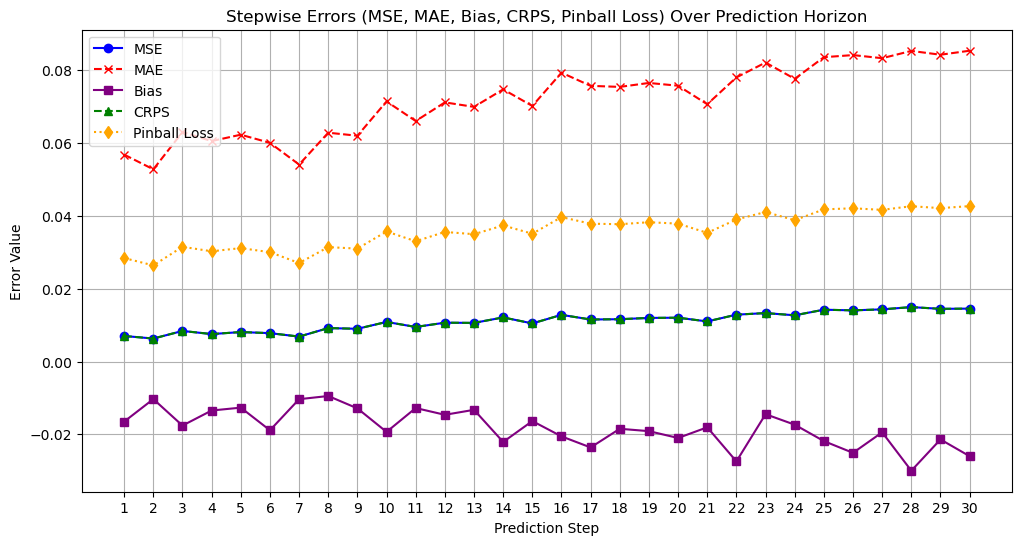

🔹 **Average MSE:** 0.0026
🔹 **Average MAE:** 0.0375
🔹 **Average Bias:** 0.0129
🔹 **Average CRPS:** 0.0026
🔹 **Average Pinball Loss:** 0.0188


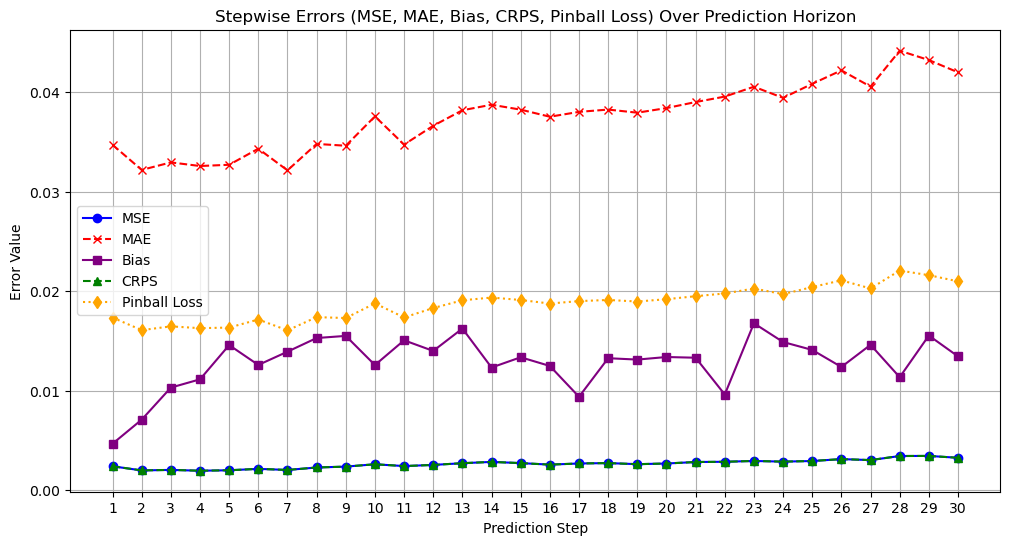

In [25]:
evaluation_plot_utils.plot_stepwise_errors(Y_test, predictions_test)
evaluation_plot_utils.plot_stepwise_errors(Y_test, corrected_forecast)

In [26]:
date_list = date_list_test
waves = {
    "Primera Onada": ("2020-03", "2020-06"),
    "Segona Onada": ("2020-10", "2020-12"),
    "Tercera Onada": ("2021-01", "2021-03"),
    "Quarta Onada": ("2021-04", "2021-06"),
    #"Cinquena Onada": ("2021-07", "2021-09")
}

# Convertir a DataFrame per facilitar la representació
df_waves = pd.DataFrame(waves).T.reset_index()
df_waves.columns = ["Onada", "Inici", "Final"]
df_waves["Inici"] = pd.to_datetime(df_waves["Inici"])
df_waves["Final"] = pd.to_datetime(df_waves["Final"])

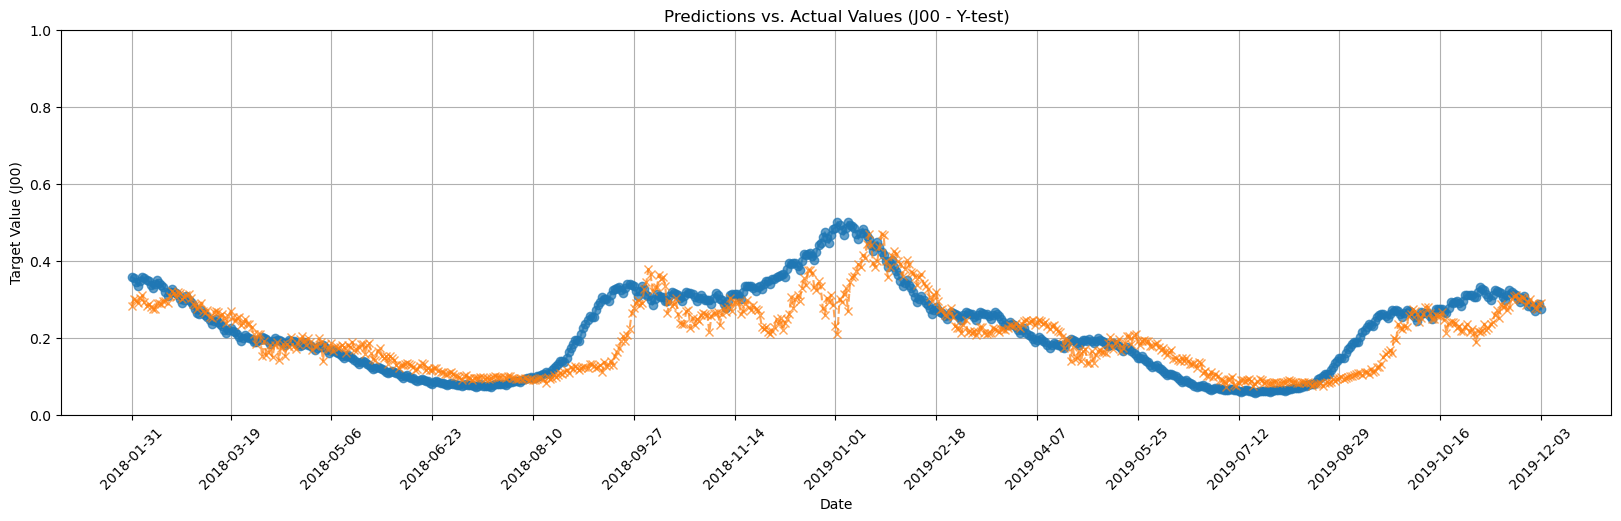

🔹 **Average MSE:** 0.0037
🔹 **Average MAE:** 0.0451
🔹 **Average Bias:** -0.0181
🔹 **Average CRPS:** 0.0037
🔹 **Average Pinball Loss:** 0.0225


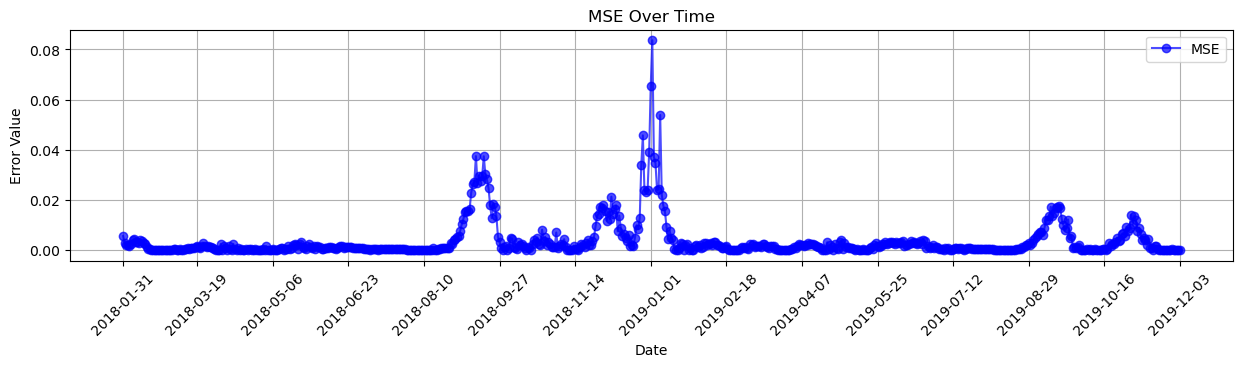

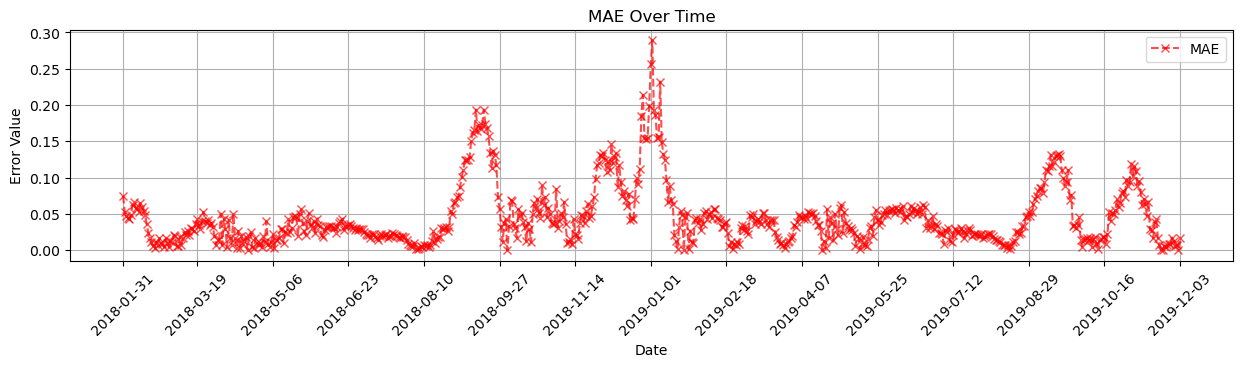

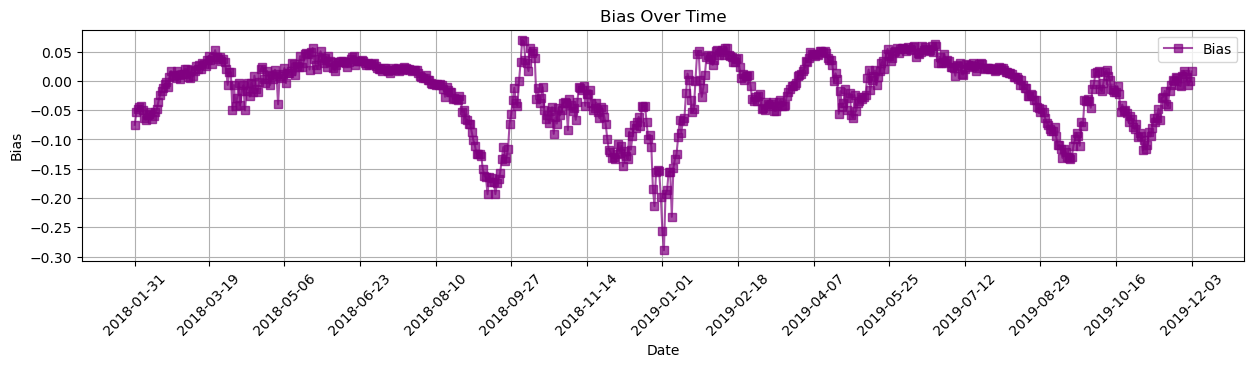

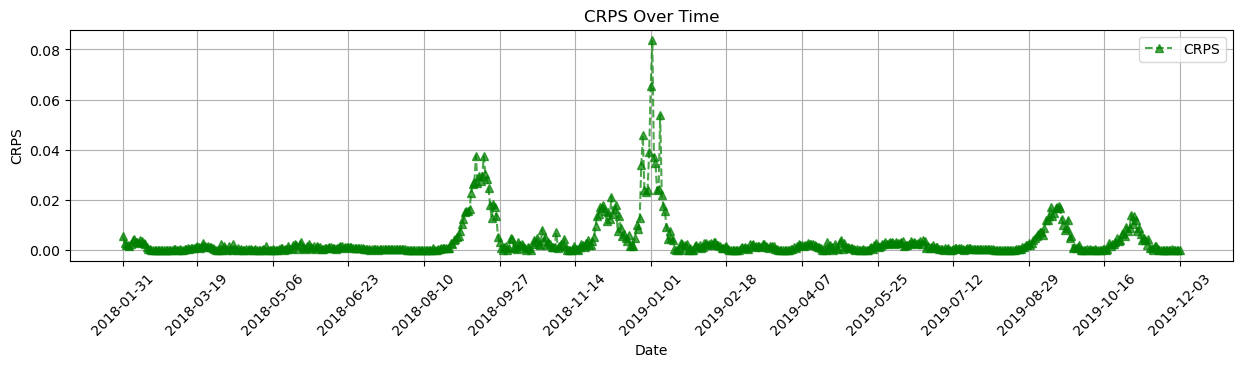

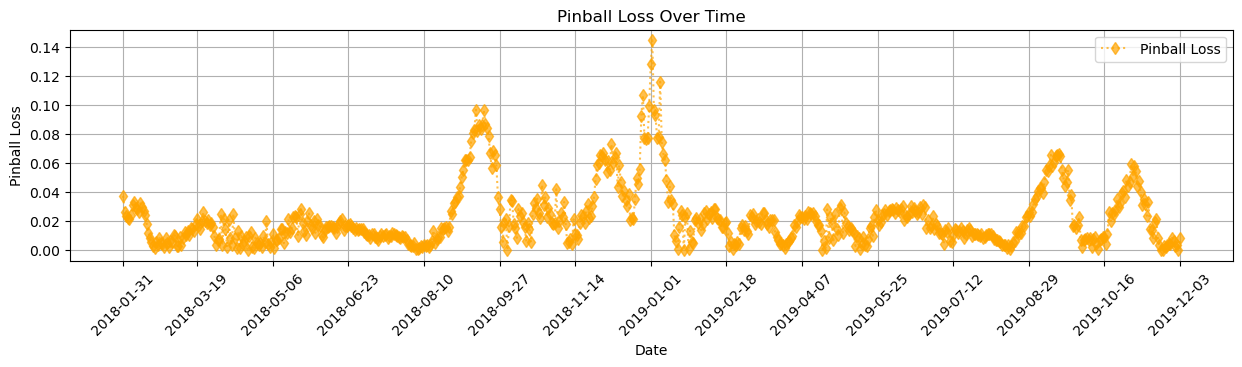


📊 **Results for MSE:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0037, Std=0.0077, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for MAE:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0451, Std=0.0413, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for Bias:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=-0.0181, Std=0.0584, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for CRPS:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0037, Std=0.0077, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for Pinball Loss:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0225, Std=0.0206, N=672
⚠️ Not enough samples to perform statistical tests.


C:\Users\34648\OneDrive - Generalitat de Catalunya\Escriptori\waikato\evaluation_plot_utils.py:262: RuntimeWarning: Mean of empty slice.
  print(f"🔹 Inside Pandemic Waves: Mean={inside.mean():.4f}, Std={inside.std():.4f}, N={len(inside)}")
D:\anaconda\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
D:\anaconda\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\anaconda\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
D:\anaconda\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [27]:
predictions_to_plot = predictions_test.mean(axis=1) 
Y_test_to_plot = Y_test.mean(axis=1)

# Call the function with formatted dates
evaluation_plot_utils.plot_predictions_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves, waves=False)

evaluation_plot_utils.plot_errors_over_time_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves, waves=False)

evaluation_plot_utils.evaluate_error_significance_pandemic_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves)

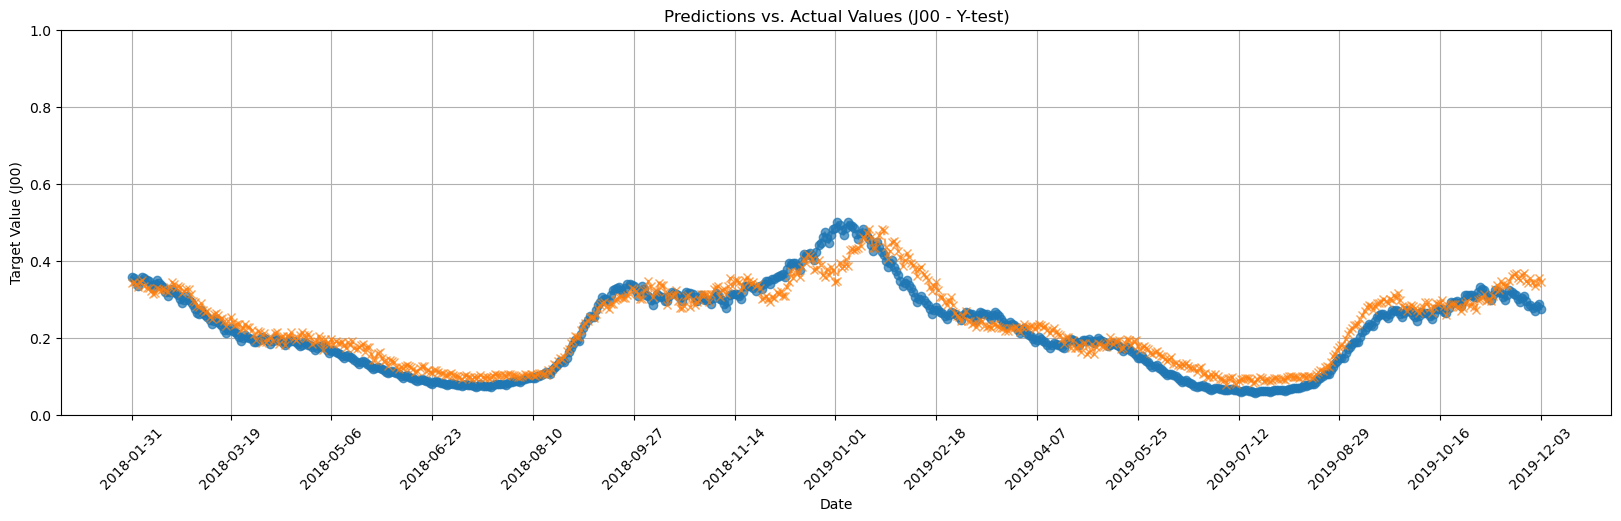

🔹 **Average MSE:** 0.0011
🔹 **Average MAE:** 0.0268
🔹 **Average Bias:** 0.0129
🔹 **Average CRPS:** 0.0011
🔹 **Average Pinball Loss:** 0.0134


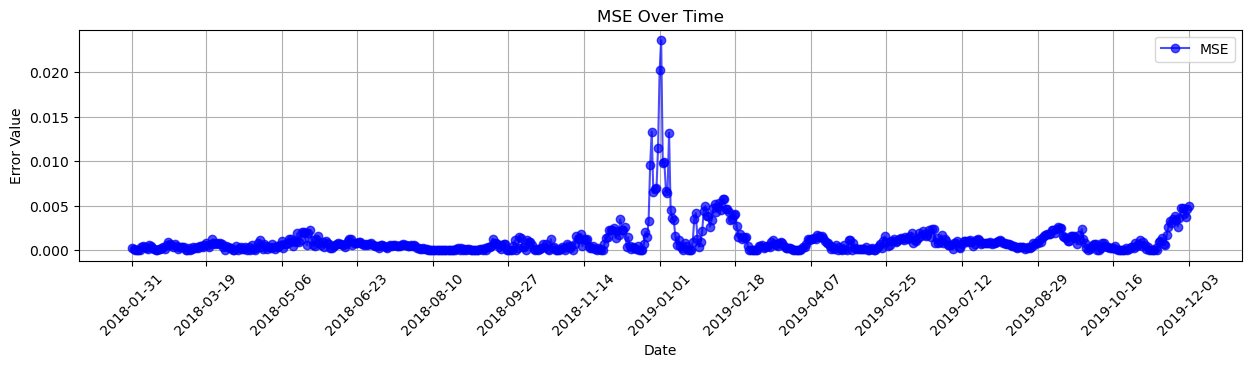

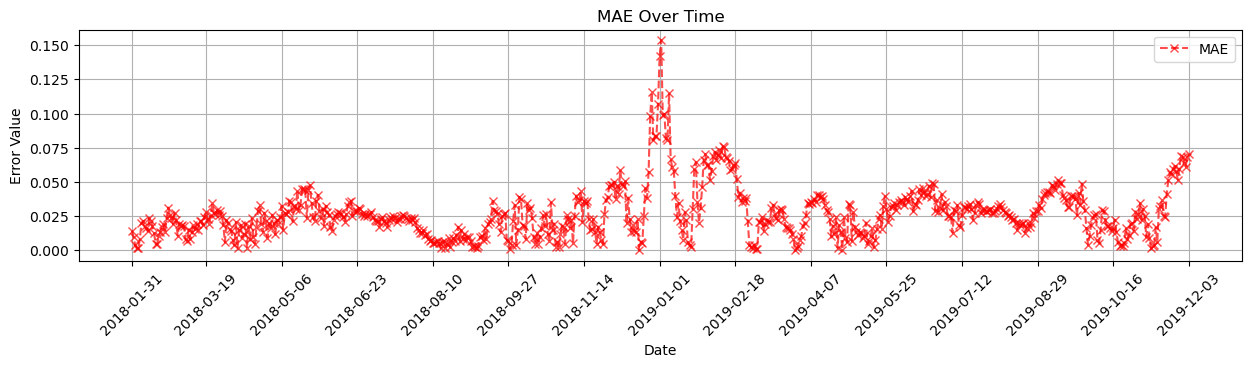

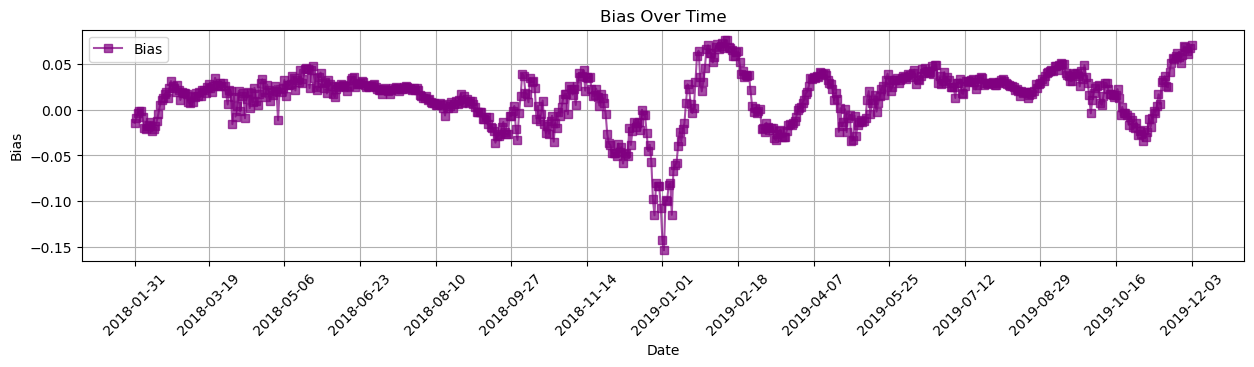

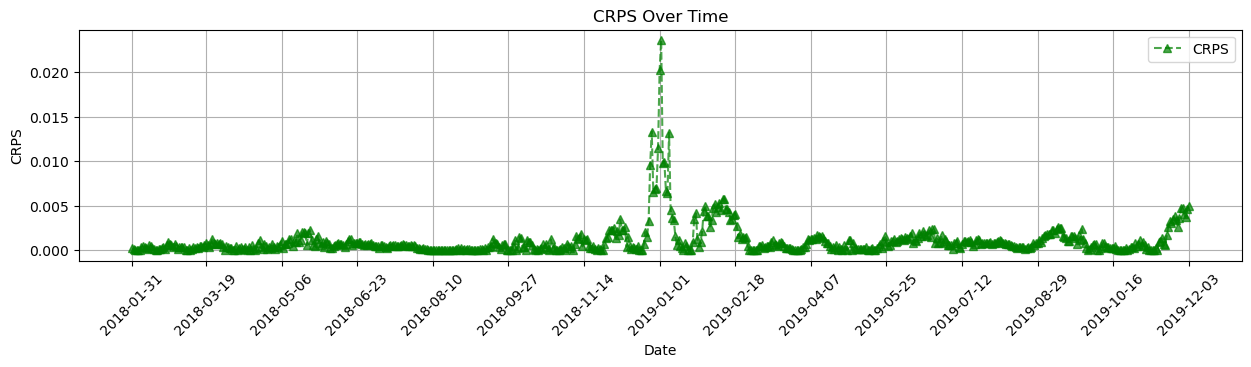

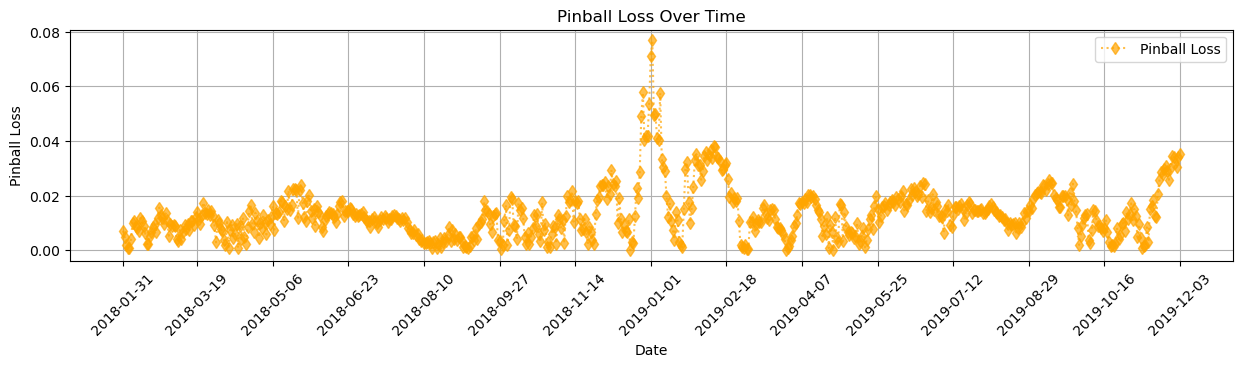


📊 **Results for MSE:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0011, Std=0.0019, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for MAE:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0268, Std=0.0189, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for Bias:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0129, Std=0.0301, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for CRPS:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0011, Std=0.0019, N=672
⚠️ Not enough samples to perform statistical tests.

📊 **Results for Pinball Loss:**
🔹 Inside Pandemic Waves: Mean=nan, Std=nan, N=0
🔹 Outside Pandemic Waves: Mean=0.0134, Std=0.0094, N=672
⚠️ Not enough samples to perform statistical tests.


C:\Users\34648\OneDrive - Generalitat de Catalunya\Escriptori\waikato\evaluation_plot_utils.py:262: RuntimeWarning: Mean of empty slice.
  print(f"🔹 Inside Pandemic Waves: Mean={inside.mean():.4f}, Std={inside.std():.4f}, N={len(inside)}")
D:\anaconda\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
D:\anaconda\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\anaconda\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
D:\anaconda\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [28]:
predictions_to_plot = corrected_forecast.mean(axis=1) 
Y_test_to_plot = Y_test.mean(axis=1)

# Call the function with formatted dates
evaluation_plot_utils.plot_predictions_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves, waves=False)

evaluation_plot_utils.plot_errors_over_time_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves, waves=False)

evaluation_plot_utils.evaluate_error_significance_pandemic_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves)

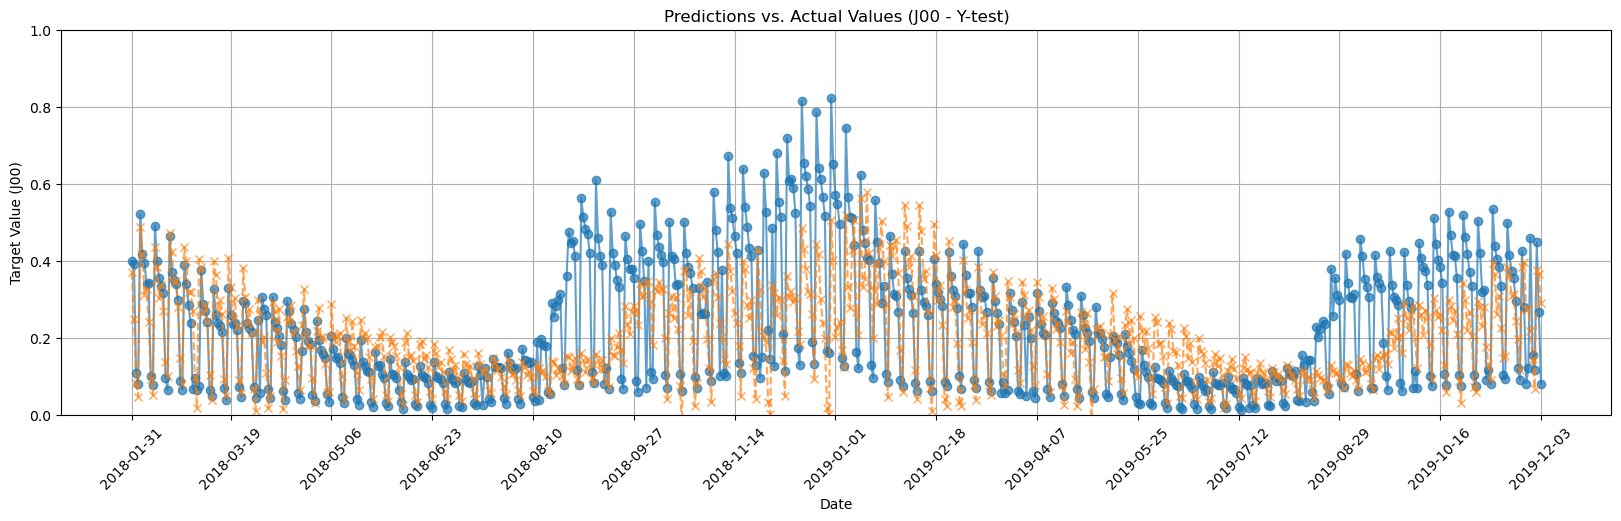

🔹 **Average MSE:** 0.0145
🔹 **Average MAE:** 0.0853
🔹 **Average Bias:** -0.0260
🔹 **Average CRPS:** 0.0145
🔹 **Average Pinball Loss:** 0.0427


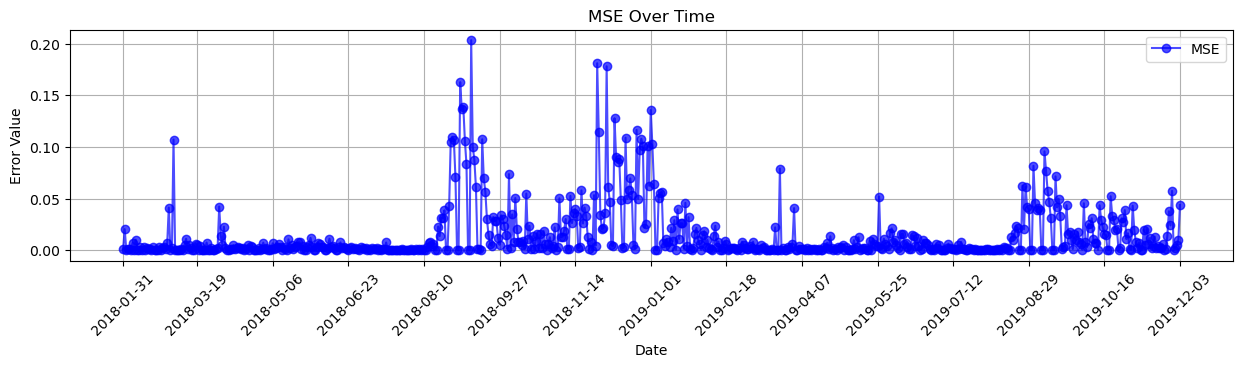

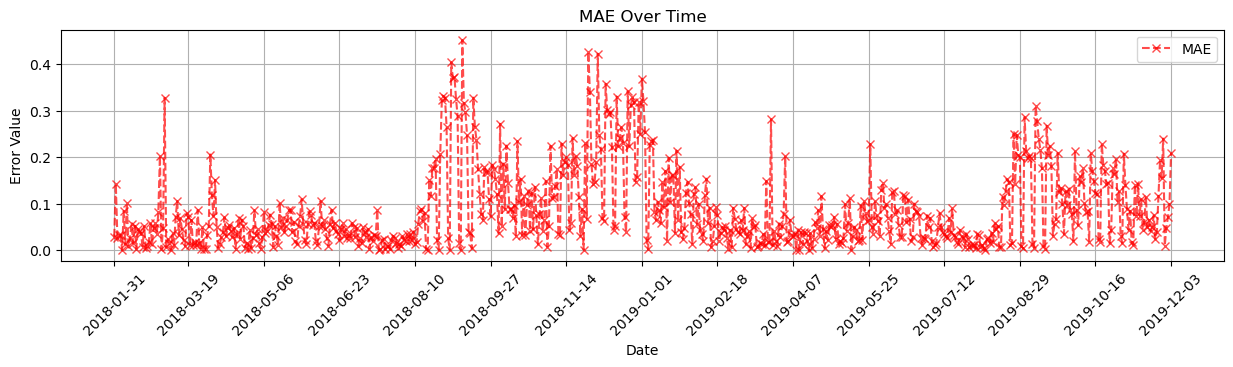

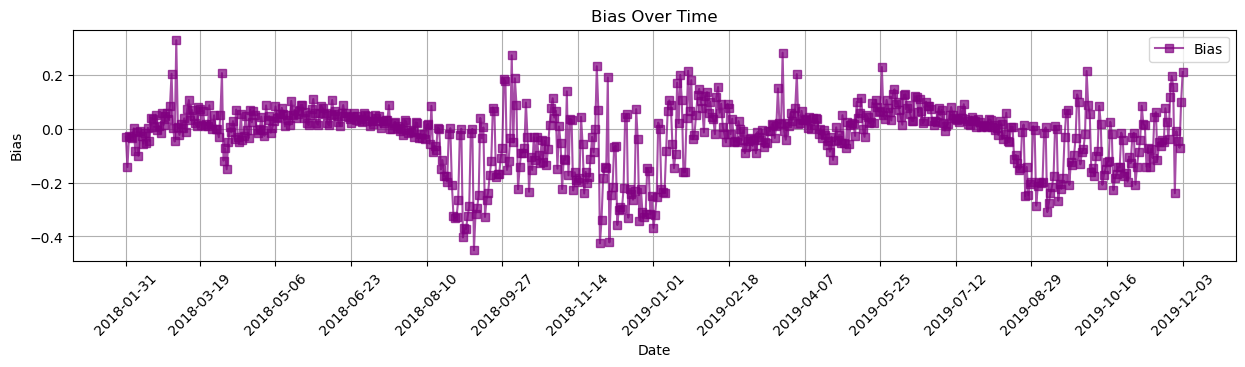

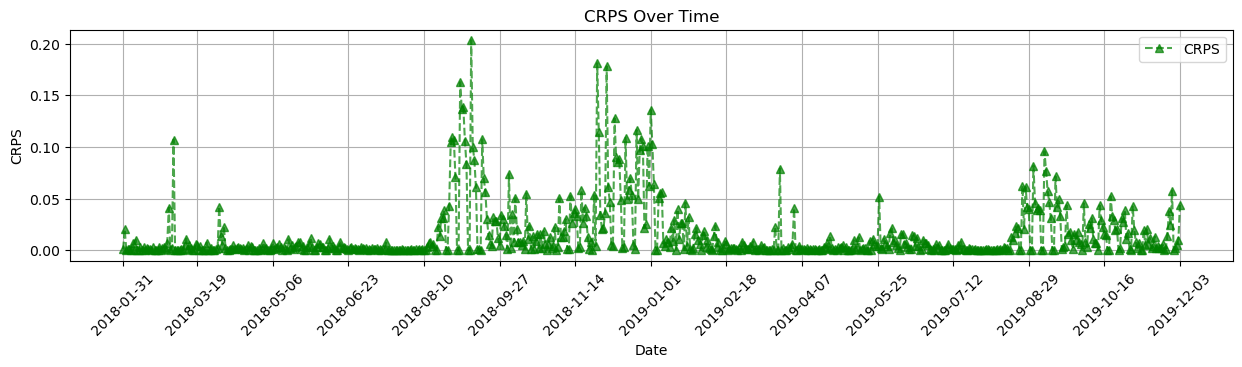

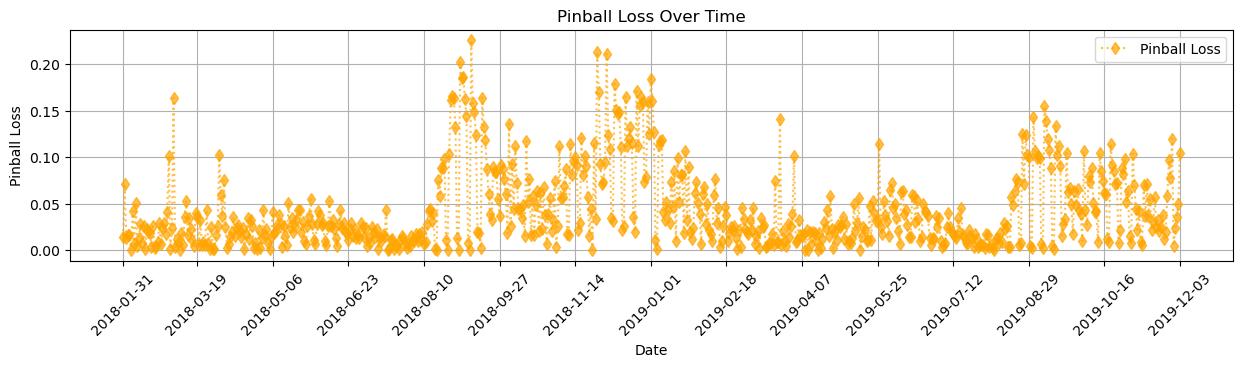

In [20]:
predictions_to_plot = predictions_test[:, -1] 
Y_test_to_plot = Y_test[:,-1]

# Call the function with formatted dates
evaluation_plot_utils.plot_predictions_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves,waves=False)

# Compute errors for each step and plot them
evaluation_plot_utils.plot_errors_over_time_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves,waves=False)

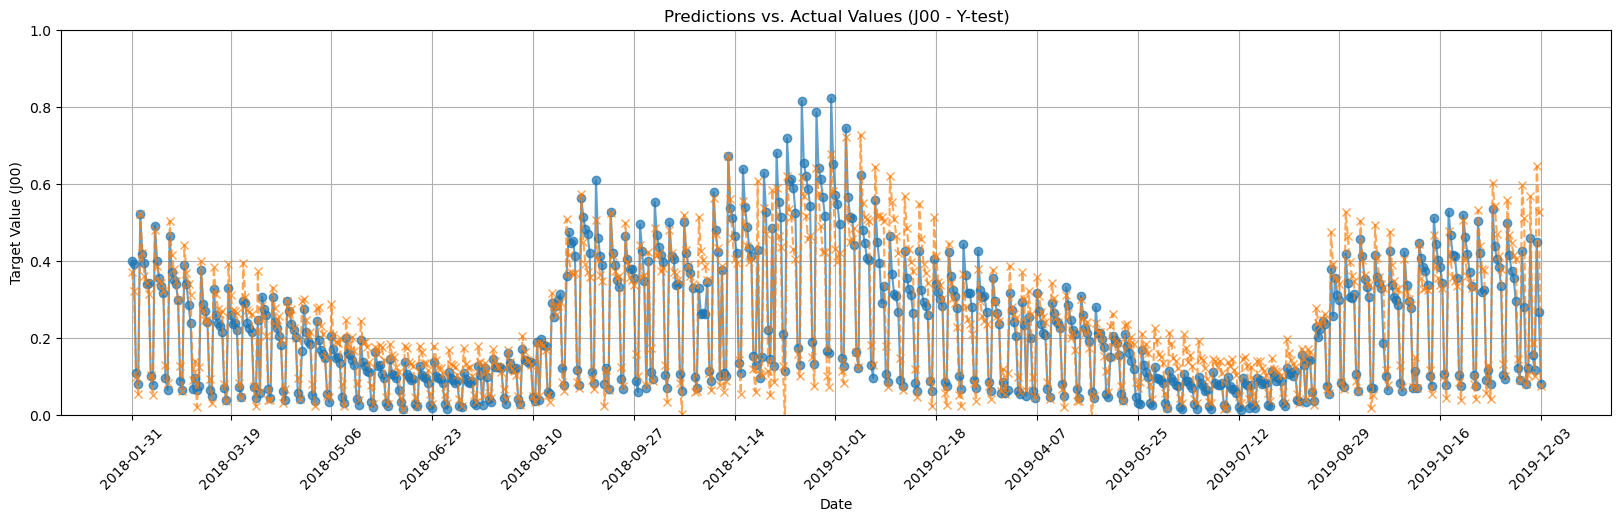

🔹 **Average MSE:** 0.0033
🔹 **Average MAE:** 0.0420
🔹 **Average Bias:** 0.0135
🔹 **Average CRPS:** 0.0033
🔹 **Average Pinball Loss:** 0.0210


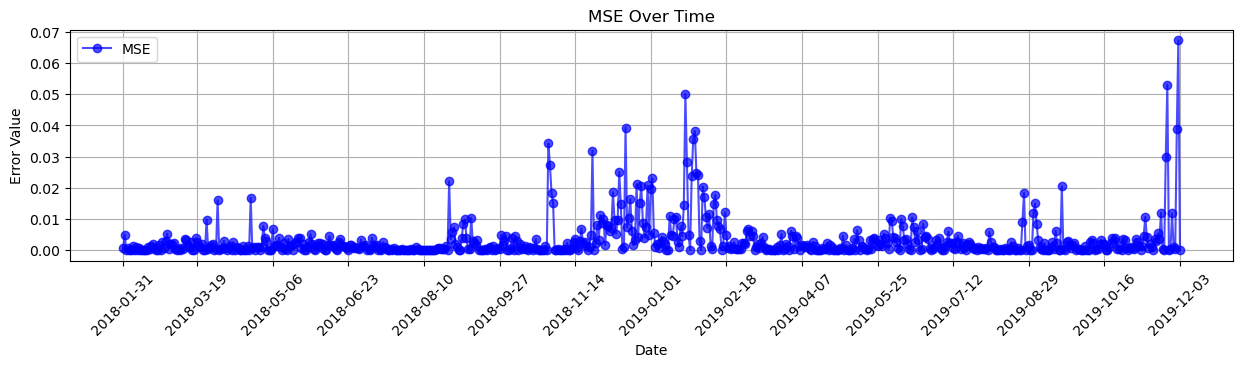

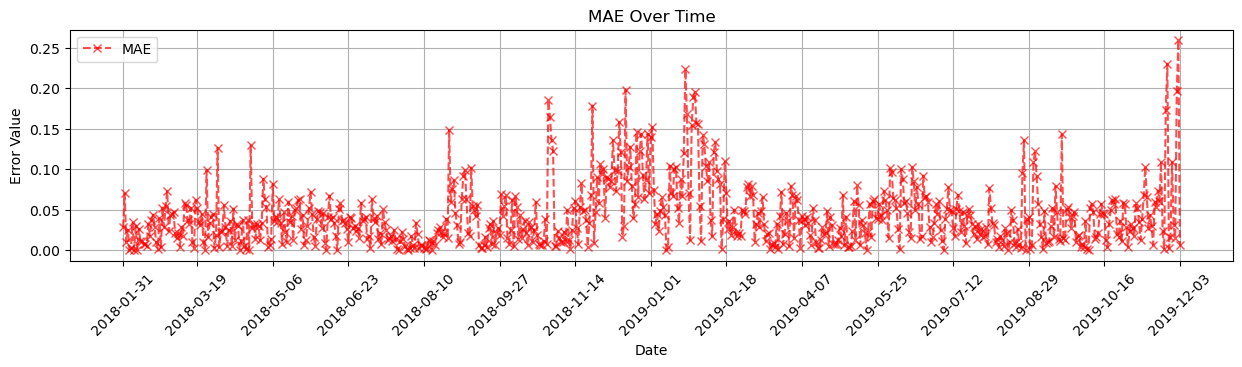

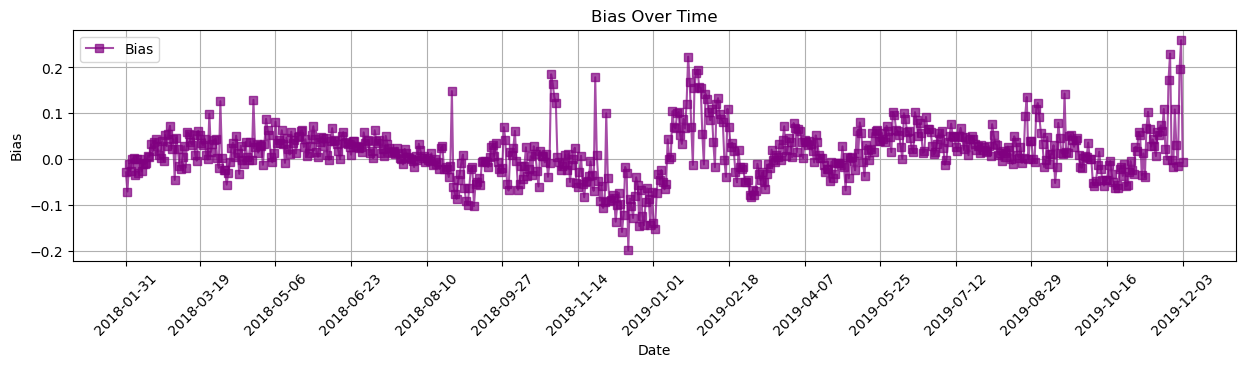

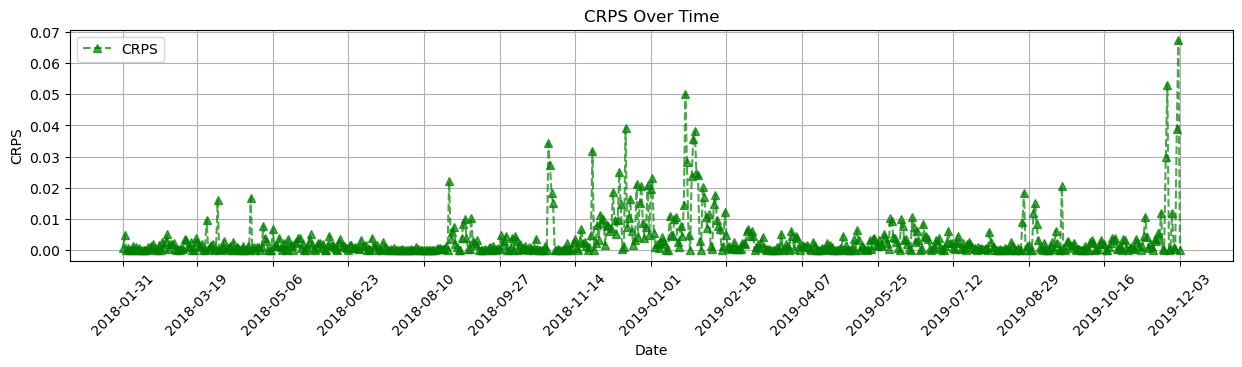

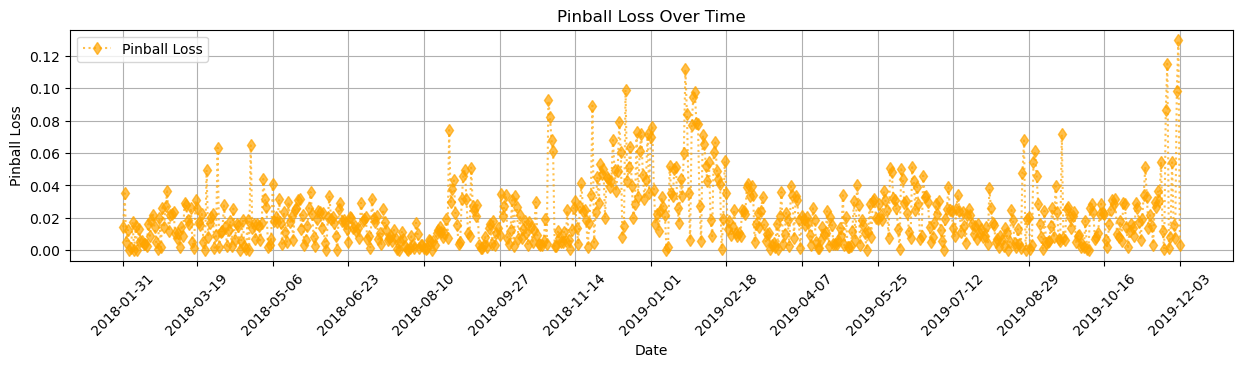

In [21]:
predictions_to_plot = corrected_forecast[:, -1] 
Y_test_to_plot = Y_test[:,-1]

# Call the function with formatted dates
evaluation_plot_utils.plot_predictions_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves,waves=False)

# Compute errors for each step and plot them
evaluation_plot_utils.plot_errors_over_time_with_waves(Y_test_to_plot, predictions_to_plot, date_list, df_waves,waves=False)

# NEXT STEPS

- Learn the derivative (rate of change)
- parameter exploration
- features (Also fixed forecast horizon)

In [37]:
# Model directory path
base_path = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/"
models_path = os.path.join(base_path, "models/")
resid_models_path = os.path.join(base_path, "residuals_models/")

# Extract all available model folders
model_folders = [folder for folder in os.listdir(models_path) if folder.startswith(f"{code}_example_transformer")]
resid_model_folders = [folder for folder in os.listdir(resid_models_path) if folder.startswith(f"{code}_SEASONAL_RESIDUALS_LEARNING")]


# Dictionary to store results per lookback period
results = {}
results_corrected = {}

# Iterate over each model
for model_folder in model_folders:

    full_path = os.path.join(models_path, model_folder)

    try:
        # Extract forecast period (`fh`) and lookback (`lb`) from the folder name
        parts = model_folder.split("_")
        if len(parts) < 7:
            raise ValueError(f"Unexpected model folder name format: {model_folder}")

        forecast_horizon = int(parts[4][:-2])  # Extract `fh` value
        lookback = int(parts[6][:-2])  # Extract `lb` value

        # Load test data
        start_time = time.perf_counter()
        X_test, Y_test = data_preparation.prepare_data(f'{base_path}diagnostic_data/{code}_test_example.csv', lookback, forecast_horizon, debug=True, univariate=True)
        finish_preparing = time.perf_counter()
        print(f"✅ Data prepared for Lookback={lookback}, Time Spent: {finish_preparing - start_time:.2f}s")

        # Load model and make predictions
        model = tf.keras.models.load_model(full_path)
        predictions = model.predict(X_test, verbose=0)

        # Resize Y_test if needed
        Y_test_resized = np.tile(Y_test[:, np.newaxis], predictions.shape[1]) if Y_test.ndim == 1 else Y_test

        # Compute error metrics
        mse = np.mean([mean_squared_error(Y_test_resized[:, step], predictions[:, step]) for step in range(predictions.shape[1])])
        mae = np.mean([mean_absolute_error(Y_test_resized[:, step], predictions[:, step]) for step in range(predictions.shape[1])])
        bias = np.mean([np.mean(predictions[:, step] - Y_test_resized[:, step]) for step in range(predictions.shape[1])])
        crps_val = evaluation_plot_utils.crps(Y_test_resized, predictions)
        pinball = evaluation_plot_utils.pinball_loss(Y_test_resized, predictions)

        # Store results
        if lookback not in results:
            results[lookback] = {"Forecast Period": [], "MSE": [], "MAE": [], "Bias": [], "CRPS": [], "Pinball Loss": []}

        results[lookback]["Forecast Period"].append(forecast_horizon)
        results[lookback]["MSE"].append(mse)
        results[lookback]["MAE"].append(mae)
        results[lookback]["Bias"].append(bias)
        results[lookback]["CRPS"].append(crps_val)
        results[lookback]["Pinball Loss"].append(pinball)

        resid_model_folder = f'{code}_SEASONAL_RESIDUALS_LEARNING_{forecast_horizon}fh_8ff_{lookback}lb_0.001initlr'
        full_path_resid = os.path.join(resid_models_path, resid_model_folder) if resid_model_folder in resid_model_folders else None

            # Process residuals model
        if full_path_resid:
            model_resid = tf.keras.models.load_model(full_path_resid)
            df = pd.read_csv(f'{base_path}diagnostic_data/{code}_test_example.csv')
            categorical_vars = ["Day_of_Week", "Month", "Season", "Holiday", "School_Vacation"]
            df_processed = data_preparation.prepare_time_series_features(df, categorical_vars)
            print(df_processed.info())
            X_test_covs = data_preparation.generate_rolling_sequences_covariates(df_processed, lookback, forecast_horizon, predictions)
            predicted_residuals = np.squeeze(model_resid.predict(X_test_covs), axis=-1)
            corrected_prediction = predictions + predicted_residuals

            # Compute corrected metrics
            mse_r = np.mean([mean_squared_error(Y_test_resized[:, step], corrected_prediction[:, step]) for step in range(corrected_prediction.shape[1])])
            mae_r = np.mean([mean_absolute_error(Y_test_resized[:, step], corrected_prediction[:, step]) for step in range(corrected_prediction.shape[1])])
            bias_r = np.mean([np.mean(corrected_prediction[:, step] - Y_test_resized[:, step]) for step in range(corrected_prediction.shape[1])])
            crps_val_r = evaluation_plot_utils.crps(Y_test_resized, corrected_prediction)
            pinball_r = evaluation_plot_utils.pinball_loss(Y_test_resized, corrected_prediction)

            if lookback not in results_corrected:
                results_corrected[lookback] = {"Forecast Period": [], "MSE": [], "MAE": [], "Bias": [], "CRPS": [], "Pinball Loss": []}

            results_corrected[lookback]["Forecast Period"].append(forecast_horizon)
            results_corrected[lookback]["MSE"].append(mse_r)
            results_corrected[lookback]["MAE"].append(mae_r)
            results_corrected[lookback]["Bias"].append(bias_r)
            results_corrected[lookback]["CRPS"].append(crps_val_r)
            results_corrected[lookback]["Pinball Loss"].append(pinball_r)

    except Exception as e:
        print(f"❌ Error loading model {model_folder}: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(704, 14, 1), Y=(704, 14)
✅ Data prepared for Lookback=14, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thur

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursday         731 non-null    uint8         
 6   Day_of_Week_Tuesday          731 non-null    uint8         
 7   Day_of_Week_Wednesday        731 non-null    uint8         
 8   Month_April                  731 non-null    uint8         
 9   Month_August                 731 non-null    uint8         
 10  Month_December               731 non-null    uint8         
 11  Month_February               731 non-null    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(520, 30, 1), Y=(520, 182)
✅ Data prepared for Lookback=30, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thu

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursday         731 non-null    uint8         
 6   Day_of_Week_Tuesday          731 non-null    uint8         
 7   Day_of_Week_Wednesday        731 non-null    uint8         
 8   Month_April                  731 non-null    uint8         
 9   Month_August                 731 non-null    uint8         
 10  Month_December               731 non-null    uint8         
 11  Month_February               731 non-null    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(724, 7, 1), Y=(724, 1)
✅ Data prepared for Lookback=7, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursda

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursday         731 non-null    uint8         
 6   Day_of_Week_Tuesday          731 non-null    uint8         
 7   Day_of_Week_Wednesday        731 non-null    uint8         
 8   Month_April                  731 non-null    uint8         
 9   Month_August                 731 non-null    uint8         
 10  Month_December               731 non-null    uint8         
 11  Month_February               731 non-null    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(337, 30, 1), Y=(337, 365)
✅ Data prepared for Lookback=30, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(307, 60, 1), Y=(307, 365)
✅ Data prepared for Lookback=60, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  731 non-null    object 
 1   J00        731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.5+ KB
Processed Data Shapes: X=(612, 60, 1), Y=(612, 60)
✅ Data prepared for Lookback=60, Time Spent: 0.01s
<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thur

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 730
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    731 non-null    datetime64[ns]
 1   Day_of_Week_Friday           731 non-null    uint8         
 2   Day_of_Week_Monday           731 non-null    uint8         
 3   Day_of_Week_Saturday         731 non-null    uint8         
 4   Day_of_Week_Sunday           731 non-null    uint8         
 5   Day_of_Week_Thursday         731 non-null    uint8         
 6   Day_of_Week_Tuesday          731 non-null    uint8         
 7   Day_of_Week_Wednesday        731 non-null    uint8         
 8   Month_April                  731 non-null    uint8         
 9   Month_August                 731 non-null    uint8         
 10  Month_December               731 non-null    uint8         
 11  Month_February               731 non-null    

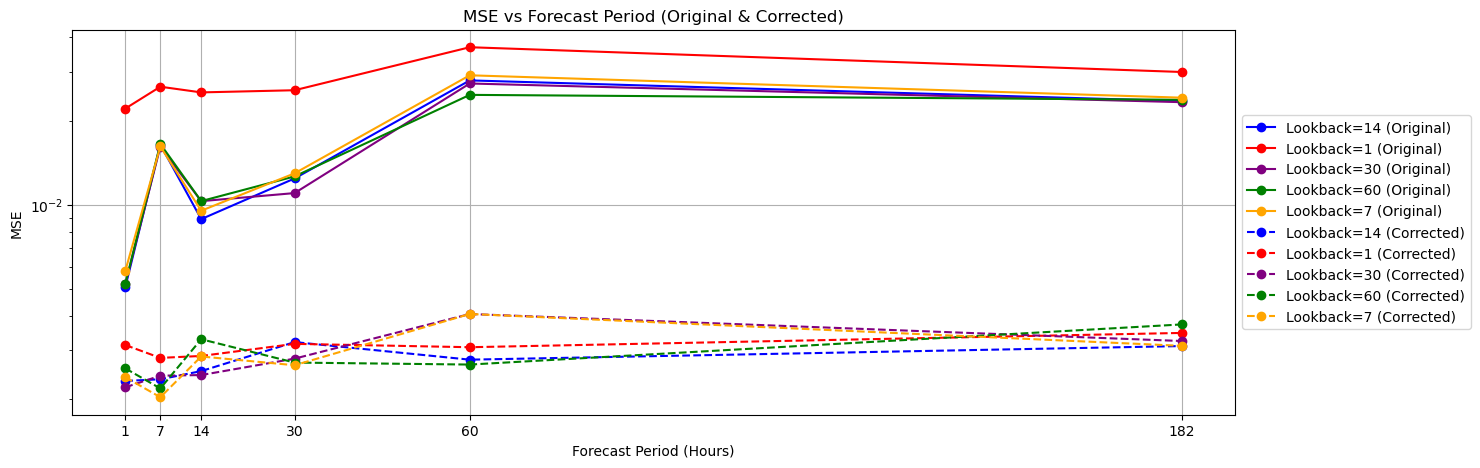

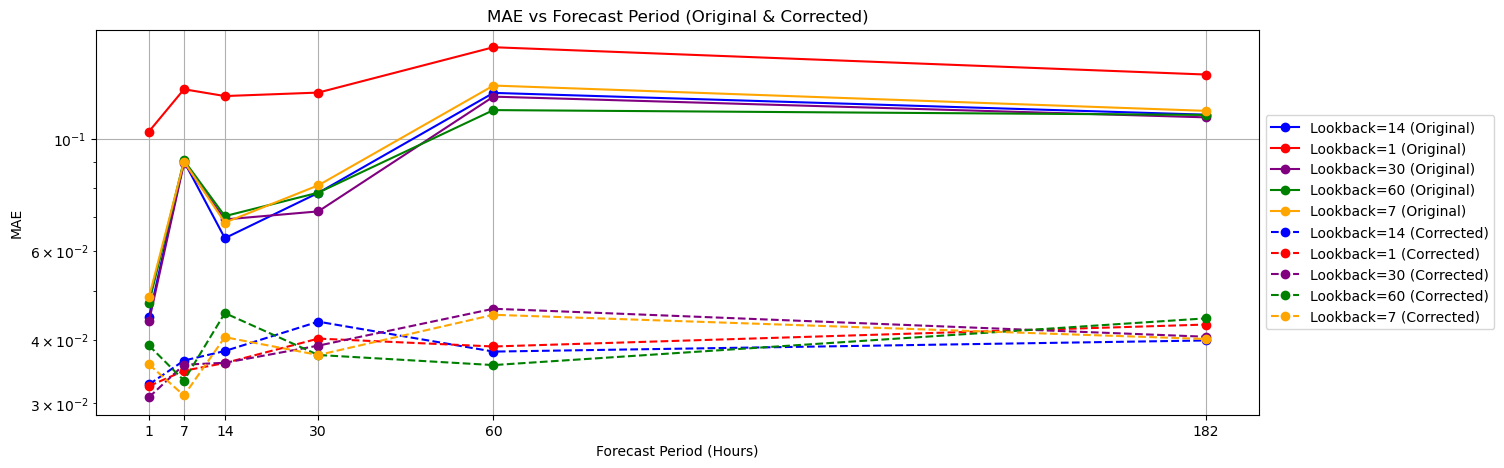

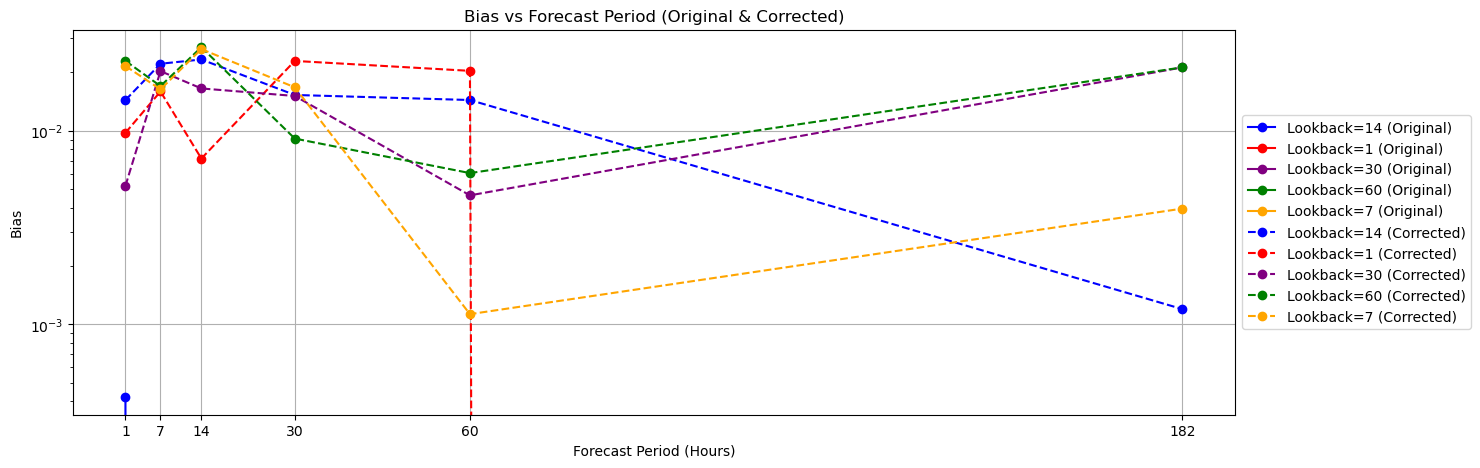

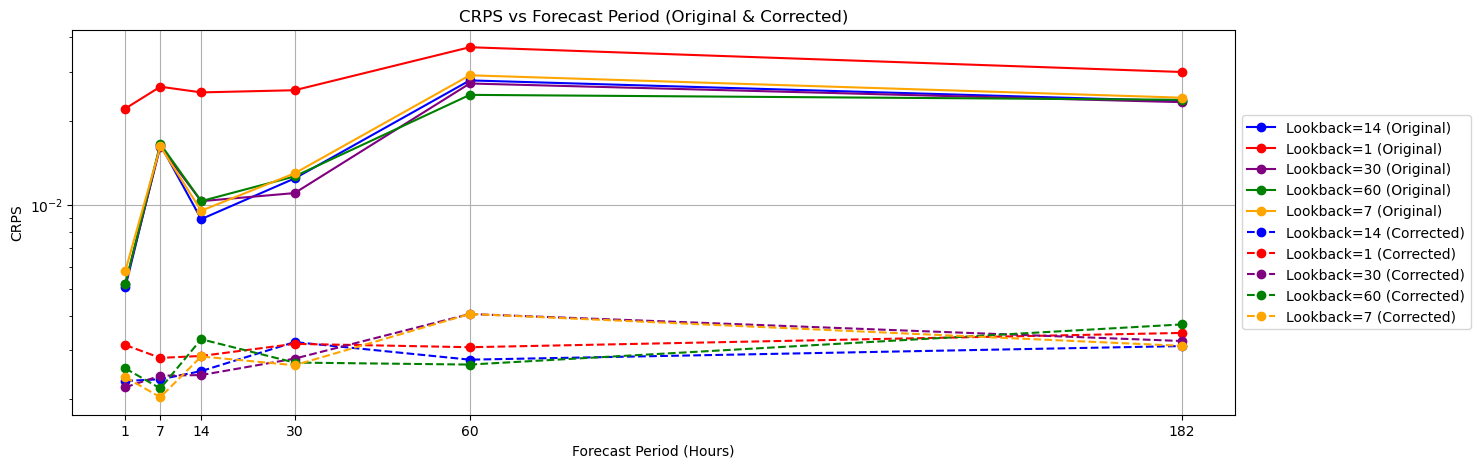

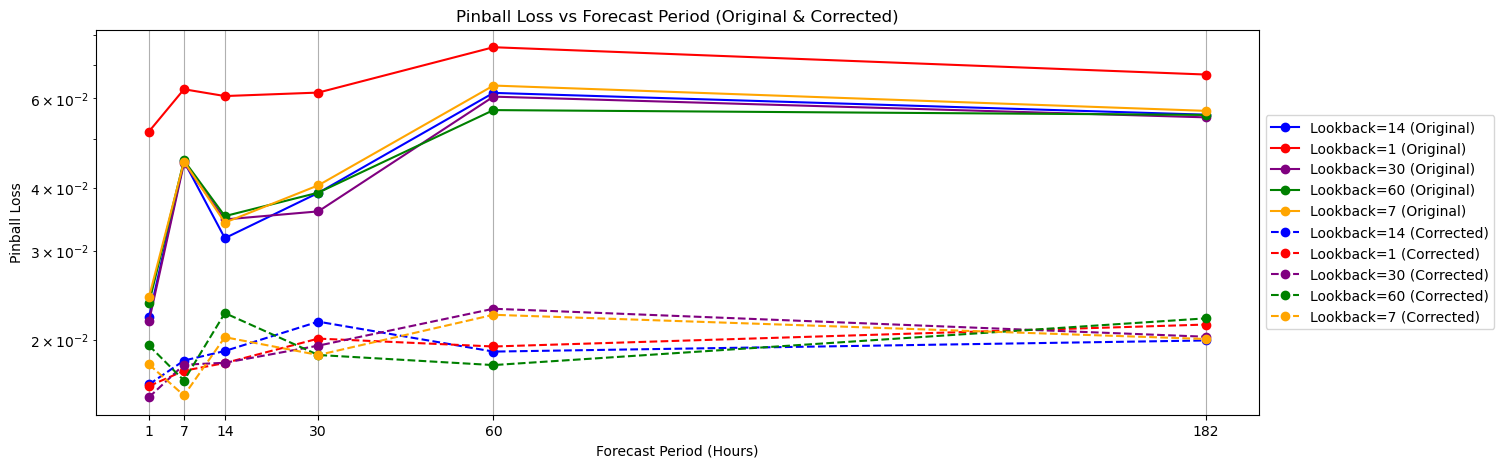

In [50]:
# 📊 Plot metrics with separate color lines for each Lookback (`lb`)
metrics = ["MSE", "MAE", "Bias", "CRPS", "Pinball Loss"]
colors = ["blue", "red", "purple", "green", "orange",'salmon','magenta']
lookback_colors = {lb: colors[i % len(colors)] for i, lb in enumerate(results.keys())}
lookback_colors_corrected = {lb: colors[i % len(colors)] for i, lb in enumerate(results_corrected.keys())}

# Plot all metrics in the same plot, color by lookback, dashed if corrected
for metric in metrics:
    plt.figure(figsize=(15, 5))
    
    # Plot original results (solid lines)
    for lookback, data in results.items():
        sorted_indices = np.argsort(data["Forecast Period"])
        x_sorted = np.array(data["Forecast Period"])[sorted_indices]
        y_sorted = np.array(data[metric])[sorted_indices]

        plt.plot(x_sorted, y_sorted, marker="o", linestyle="-", color=lookback_colors[lookback], label=f"Lookback={lookback} (Original)")

    # Plot corrected results (dashed lines)
    for lookback, data in results_corrected.items():
        sorted_indices = np.argsort(data["Forecast Period"])
        x_sorted = np.array(data["Forecast Period"])[sorted_indices]
        y_sorted = np.array(data[metric])[sorted_indices]

        plt.plot(x_sorted, y_sorted, marker="o", linestyle="--", color=lookback_colors_corrected[lookback], label=f"Lookback={lookback} (Corrected)")

    plt.xlabel("Forecast Period (Hours)")
    plt.yscale("log") 
    plt.ylabel(metric)
    plt.title(f"{metric} vs Forecast Period (Original & Corrected)")
    plt.xticks(x_sorted)
    plt.legend()
    plt.grid(True)
    
    # Move legend to the right
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.show()